<a href="https://colab.research.google.com/github/tejas883/Roll_No_32_Machine-Learning-Lab/blob/main/ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.

Name : Tejas Surendra Mule

Roll No : CS32


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [ ]:
# Task 1: Environment Setup and Dataset Acquisition

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Upload CSV file manually
from google.colab import files

uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Load the CSV file
df = pd.read_csv(file_name)

# Assign column headers
df.columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# Display first five records
print("First Five Records:")
display(df.head())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display data types
print("\nData Types:")
print(df.dtypes)

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

Saving diabetes.csv to diabetes.csv
First Five Records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



Dataset Shape:
(768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Counts:
Non-Diabetic (0): 500
Diabetic (1): 268

Class Percentages:
Non-Diabetic (0): 65.1 %
Diabetic (1): 34.9 %


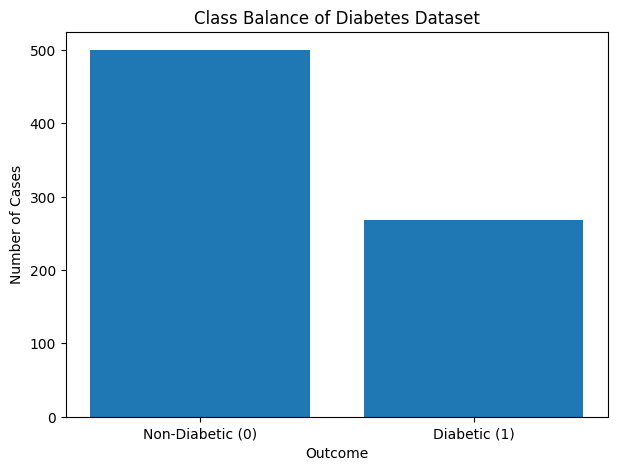

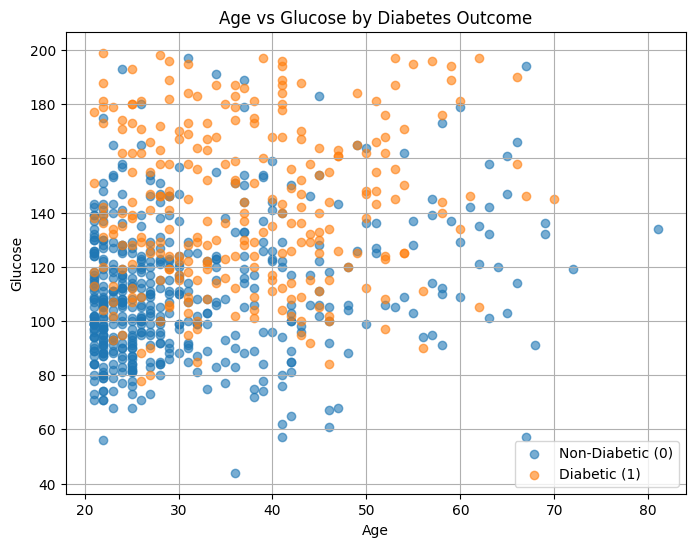

In [ ]:
# Task 2: Exploratory Data Analysis (EDA)

# --------------------------------------------------
# 1. Class Balance: Count and Percentage
# --------------------------------------------------

# Calculate absolute count of each class
class_counts = df['Outcome'].value_counts().sort_index()

# Calculate percentage of each class
class_percentages = df['Outcome'].value_counts(normalize=True).sort_index() * 100

print("Class Counts:")
print("Non-Diabetic (0):", class_counts[0])
print("Diabetic (1):", class_counts[1])

print("\nClass Percentages:")
print("Non-Diabetic (0):", round(class_percentages[0], 2), "%")
print("Diabetic (1):", round(class_percentages[1], 2), "%")


# --------------------------------------------------
# Bar Chart: Class Balance
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.bar(
    ['Non-Diabetic (0)', 'Diabetic (1)'],
    class_counts.values
)

plt.xlabel('Outcome')
plt.ylabel('Number of Cases')
plt.title('Class Balance of Diabetes Dataset')

plt.show()


# --------------------------------------------------
# 2. Scatter Plot: Age vs Glucose
# --------------------------------------------------

plt.figure(figsize=(8, 6))

# Plot non-diabetic cases
plt.scatter(
    df[df['Outcome'] == 0]['Age'],
    df[df['Outcome'] == 0]['Glucose'],
    label='Non-Diabetic (0)',
    alpha=0.6
)

# Plot diabetic cases
plt.scatter(
    df[df['Outcome'] == 1]['Age'],
    df[df['Outcome'] == 1]['Glucose'],
    label='Diabetic (1)',
    alpha=0.6
)

plt.xlabel('Age')
plt.ylabel('Glucose')
plt.title('Age vs Glucose by Diabetes Outcome')
plt.legend()
plt.grid(True)

plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [ ]:
# Task 3: Preprocessing and Handling Missing Values

import numpy as np
import pandas as pd

# --------------------------------------------------
# 1. Identify features where 0 is physically impossible
# --------------------------------------------------

invalid_features = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

print("Features where 0 is considered invalid:")
print(invalid_features)


# --------------------------------------------------
# 2. Replace invalid 0 values with NaN
# --------------------------------------------------

# Make a copy of the dataset
df_clean = df.copy()

# Replace 0 with NaN in selected columns
df_clean[invalid_features] = df_clean[invalid_features].replace(0, np.nan)

print("\nMissing values after replacing 0 with NaN:")
print(df_clean[invalid_features].isnull().sum())


# --------------------------------------------------
# 3. Handle missing values using median imputation
# --------------------------------------------------

for column in invalid_features:
    median_value = df_clean[column].median()
    df_clean[column] = df_clean[column].fillna(median_value)

print("\nMissing values after median imputation:")
print(df_clean[invalid_features].isnull().sum())


# --------------------------------------------------
# Display the cleaned dataset
# --------------------------------------------------

print("\nFirst five records after preprocessing:")
display(df_clean.head())

Features where 0 is considered invalid:
['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

Missing values after replacing 0 with NaN:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Missing values after median imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

First five records after preprocessing:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [ ]:
# Task 4: Stratified Train-Test Splitting

from sklearn.model_selection import train_test_split

# --------------------------------------------------
# 1. Separate features (X) and target (y)
# --------------------------------------------------

# First 8 columns = Features
X = df_clean.iloc[:, :8]

# 9th column = Target
y = df_clean.iloc[:, 8]

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)


# --------------------------------------------------
# 2. Split into 80% Training and 20% Testing
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# --------------------------------------------------
# Display the shapes
# --------------------------------------------------

print("\nTraining Data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting Data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


# --------------------------------------------------
# Check class proportions
# --------------------------------------------------

print("\nClass distribution in original dataset:")
print(y.value_counts(normalize=True) * 100)

print("\nClass distribution in training dataset:")
print(y_train.value_counts(normalize=True) * 100)

print("\nClass distribution in test dataset:")
print(y_test.value_counts(normalize=True) * 100)

Feature matrix X shape: (768, 8)
Target vector y shape: (768,)

Training Data:
X_train: (614, 8)
y_train: (614,)

Testing Data:
X_test: (154, 8)
y_test: (154,)

Class distribution in original dataset:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Class distribution in training dataset:
Outcome
0    65.14658
1    34.85342
Name: proportion, dtype: float64

Class distribution in test dataset:
Outcome
0    64.935065
1    35.064935
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [ ]:
# Task 5: Custom Bootstrap Sampling Function

import numpy as np

# --------------------------------------------------
# 1. Define Bootstrap Sampling Function
# --------------------------------------------------

def get_bootstrap_sample(X, y):
    """
    Creates a bootstrap sample using sampling with replacement.

    Parameters:
        X : Feature matrix
        y : Target vector

    Returns:
        X_bootstrap : Resampled feature matrix
        y_bootstrap : Resampled target vector
        sample_indices : Original indices selected
    """

    # Number of observations in training data
    N = len(X)

    # Generate random indices with replacement
    sample_indices = np.random.choice(
        N,
        size=N,
        replace=True
    )

    # Create bootstrap samples
    X_bootstrap = X.iloc[sample_indices].copy()
    y_bootstrap = y.iloc[sample_indices].copy()

    return X_bootstrap, y_bootstrap, sample_indices


# --------------------------------------------------
# 2. Generate Bootstrap Sample
# --------------------------------------------------

np.random.seed(42)

X_bootstrap, y_bootstrap, sample_indices = get_bootstrap_sample(
    X_train,
    y_train
)


# --------------------------------------------------
# 3. Display Bootstrap Sample Size
# --------------------------------------------------

print("Original training set size:", len(X_train))
print("Bootstrap sample size:", len(X_bootstrap))

print("\nX_bootstrap shape:", X_bootstrap.shape)
print("y_bootstrap shape:", y_bootstrap.shape)


# --------------------------------------------------
# 4. Check for Duplicated Original Indices
# --------------------------------------------------

unique_indices, counts = np.unique(
    sample_indices,
    return_counts=True
)

duplicated_indices = unique_indices[counts > 1]

print("\nNumber of unique rows selected:",
      len(unique_indices))

print("Number of duplicated rows:",
      len(duplicated_indices))

print("\nSome duplicated original indices:")
print(duplicated_indices[:10])


# --------------------------------------------------
# 5. Find Out-of-Bag (OOB) Samples
# --------------------------------------------------

all_indices = np.arange(len(X_train))

oob_indices = np.setdiff1d(
    all_indices,
    unique_indices
)

print("\nNumber of OOB samples:",
      len(oob_indices))

print("\nSome OOB original indices:")
print(oob_indices[:10])

Original training set size: 614
Bootstrap sample size: 614

X_bootstrap shape: (614, 8)
y_bootstrap shape: (614,)

Number of unique rows selected: 377
Number of duplicated rows: 164

Some duplicated original indices:
[ 1  4  8 11 14 20 21 27 32 34]

Number of OOB samples: 237

Some OOB original indices:
[ 2  3  5  6 10 12 23 25 29 30]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [ ]:
# Task 6: Growing the Ensemble of Base Classifiers

import numpy as np
from sklearn.tree import DecisionTreeClassifier

# --------------------------------------------------
# 1. Initialize the ensemble
# --------------------------------------------------

# Number of bootstrap iterations / decision trees
B = 50

# Empty list to store trained decision trees
ensemble_models = []


# --------------------------------------------------
# 2. Train B Decision Trees
# --------------------------------------------------

# Set random seed for reproducibility
np.random.seed(42)

for b in range(B):

    # Generate a bootstrap sample
    X_bootstrap, y_bootstrap, sample_indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create a fully grown Decision Tree
    model = DecisionTreeClassifier(
        max_depth=None,
        random_state=b
    )

    # Train the model on bootstrap data
    model.fit(X_bootstrap, y_bootstrap)

    # Add the trained model to the ensemble
    ensemble_models.append(model)


# --------------------------------------------------
# 3. Verify the Ensemble
# --------------------------------------------------

print("Number of Decision Trees in the ensemble:", len(ensemble_models))

print("\nEnsemble successfully created.")

# Display information about the first tree
print("\nFirst Decision Tree:")
print("Maximum depth setting:", ensemble_models[0].max_depth)
print("Actual tree depth:", ensemble_models[0].get_depth())


Number of Decision Trees in the ensemble: 50

Ensemble successfully created.

First Decision Tree:
Maximum depth setting: None
Actual tree depth: 9


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [ ]:
# Task 7: Implementing Aggregation (Majority Voting) from Scratch

import numpy as np

# --------------------------------------------------
# Custom Bagging Prediction Function
# --------------------------------------------------

def custom_bagging_predict(ensemble, X_test):
    """
    Generate final predictions using majority voting.

    Parameters:
        ensemble : List of trained decision tree models
        X_test   : Test feature matrix

    Returns:
        final_predictions : Majority-voted predictions
    """

    # Store predictions from every tree
    all_predictions = []

    # Get predictions from each decision tree
    for model in ensemble:
        predictions = model.predict(X_test)
        all_predictions.append(predictions)

    # Convert list to NumPy array
    all_predictions = np.array(all_predictions)

    # Shape:
    # Rows    = Decision Trees
    # Columns = Test samples
    print("Shape of all model predictions:", all_predictions.shape)

    # --------------------------------------------------
    # Majority Voting
    # --------------------------------------------------

    final_predictions = []

    # Process each test sample
    for i in range(all_predictions.shape[1]):

        # Get votes from all trees for this sample
        votes = all_predictions[:, i]

        # Count votes for class 0 and class 1
        count_class_0 = np.sum(votes == 0)
        count_class_1 = np.sum(votes == 1)

        # Select class with the highest number of votes
        if count_class_1 > count_class_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    # Convert final predictions to NumPy array
    return np.array(final_predictions)


# --------------------------------------------------
# Generate Final Bagging Predictions
# --------------------------------------------------

y_pred = custom_bagging_predict(
    ensemble_models,
    X_test
)


# --------------------------------------------------
# Display Results
# --------------------------------------------------

print("\nFinal Predictions:")
print(y_pred)

print("\nNumber of Test Samples:", len(y_pred))

print("Unique Predicted Classes:", np.unique(y_pred))

Shape of all model predictions: (50, 154)

Final Predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 1 1 0
 0 1 0 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0
 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 1
 0 0 0 0 1 0]

Number of Test Samples: 154
Unique Predicted Classes: [0 1]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [ ]:
# Task 8: Single Classifier vs. Bagging Performance Comparison

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# --------------------------------------------------
# 1. Train a Single Fully-Grown Decision Tree
# --------------------------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

# Train on ORIGINAL training data
single_tree.fit(X_train, y_train)


# --------------------------------------------------
# 2. Make Predictions
# --------------------------------------------------

# Single Decision Tree prediction
y_pred_single = single_tree.predict(X_test)

# Bagging prediction using our custom function
y_pred_bagging = custom_bagging_predict(
    ensemble_models,
    X_test
)


# --------------------------------------------------
# 3. Confusion Matrices
# --------------------------------------------------

cm_single = confusion_matrix(y_test, y_pred_single)
cm_bagging = confusion_matrix(y_test, y_pred_bagging)

print("Confusion Matrix - Single Decision Tree:")
print(cm_single)

print("\nConfusion Matrix - Bagging:")
print(cm_bagging)


# --------------------------------------------------
# 4. Calculate Performance Metrics
# --------------------------------------------------

# Single Decision Tree
accuracy_single = accuracy_score(y_test, y_pred_single)
precision_single = precision_score(y_test, y_pred_single, zero_division=0)
recall_single = recall_score(y_test, y_pred_single, zero_division=0)
f1_single = f1_score(y_test, y_pred_single, zero_division=0)


# Bagging
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging, zero_division=0)
recall_bagging = recall_score(y_test, y_pred_bagging, zero_division=0)
f1_bagging = f1_score(y_test, y_pred_bagging, zero_division=0)


# --------------------------------------------------
# 5. Print Performance Results
# --------------------------------------------------

print("\n" + "=" * 60)
print("PERFORMANCE COMPARISON")
print("=" * 60)

print("\nSingle Decision Tree:")
print("Accuracy :", round(accuracy_single, 4))
print("Precision:", round(precision_single, 4))
print("Recall   :", round(recall_single, 4))
print("F1-Score :", round(f1_single, 4))

print("\nBagging Ensemble:")
print("Accuracy :", round(accuracy_bagging, 4))
print("Precision:", round(precision_bagging, 4))
print("Recall   :", round(recall_bagging, 4))
print("F1-Score :", round(f1_bagging, 4))


# --------------------------------------------------
# 6. Comparison Table
# --------------------------------------------------

results = {
    'Model': [
        'Single Decision Tree',
        'Bagging Ensemble'
    ],
    'Accuracy': [
        accuracy_single,
        accuracy_bagging
    ],
    'Precision': [
        precision_single,
        precision_bagging
    ],
    'Recall': [
        recall_single,
        recall_bagging
    ],
    'F1-Score': [
        f1_single,
        f1_bagging
    ]
}

results_df = pd.DataFrame(results)

print("\nPerformance Comparison Table:")
display(results_df.round(4))

Shape of all model predictions: (50, 154)
Confusion Matrix - Single Decision Tree:
[[87 13]
 [16 38]]

Confusion Matrix - Bagging:
[[90 10]
 [11 43]]

PERFORMANCE COMPARISON

Single Decision Tree:
Accuracy : 0.8117
Precision: 0.7451
Recall   : 0.7037
F1-Score : 0.7238

Bagging Ensemble:
Accuracy : 0.8636
Precision: 0.8113
Recall   : 0.7963
F1-Score : 0.8037

Performance Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score
0,Single Decision Tree,0.8117,0.7451,0.7037,0.7238
1,Bagging Ensemble,0.8636,0.8113,0.7963,0.8037


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

Probability array shape: (50, 154)
Bagging probability shape: (154,)


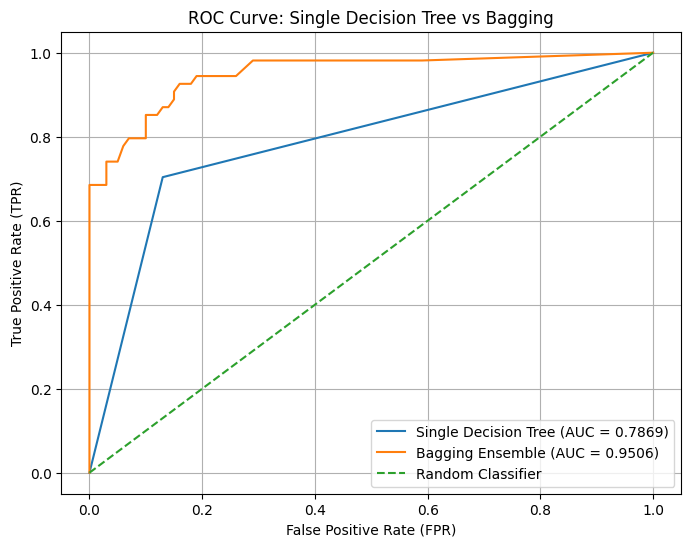


ROC-AUC COMPARISON
Single Decision Tree AUC : 0.7869
Bagging Ensemble AUC     : 0.9506

AUC Improvement          : 0.1637


In [ ]:
# Task 9: ROC-AUC Analysis and Curve Visualization

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# --------------------------------------------------
# 1. Single Decision Tree Probabilities
# --------------------------------------------------

# Probability of class 1 (Diabetic)
y_prob_single = single_tree.predict_proba(X_test)[:, 1]


# --------------------------------------------------
# 2. Bagging Probability Estimates
# --------------------------------------------------

# Store probability predictions from all decision trees
all_probabilities = []

for model in ensemble_models:

    # Get probability for class 1
    prob = model.predict_proba(X_test)[:, 1]

    all_probabilities.append(prob)

# Convert to NumPy array
all_probabilities = np.array(all_probabilities)

print("Probability array shape:",
      all_probabilities.shape)


# --------------------------------------------------
# 3. Average Probabilities Across All Trees
# --------------------------------------------------

y_prob_bagging = np.mean(
    all_probabilities,
    axis=0
)

print("Bagging probability shape:",
      y_prob_bagging.shape)


# --------------------------------------------------
# 4. Calculate ROC Curves
# --------------------------------------------------

fpr_single, tpr_single, thresholds_single = roc_curve(
    y_test,
    y_prob_single
)

fpr_bagging, tpr_bagging, thresholds_bagging = roc_curve(
    y_test,
    y_prob_bagging
)


# --------------------------------------------------
# 5. Calculate AUC
# --------------------------------------------------

auc_single = roc_auc_score(
    y_test,
    y_prob_single
)

auc_bagging = roc_auc_score(
    y_test,
    y_prob_bagging
)


# --------------------------------------------------
# 6. Plot ROC Curves
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_single,
    tpr_single,
    label=f'Single Decision Tree (AUC = {auc_single:.4f})'
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f'Bagging Ensemble (AUC = {auc_bagging:.4f})'
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve: Single Decision Tree vs Bagging')
plt.legend()
plt.grid(True)

plt.show()


# --------------------------------------------------
# 7. Print AUC Results
# --------------------------------------------------

print("\n" + "=" * 50)
print("ROC-AUC COMPARISON")
print("=" * 50)

print(f"Single Decision Tree AUC : {auc_single:.4f}")
print(f"Bagging Ensemble AUC     : {auc_bagging:.4f}")

print(f"\nAUC Improvement          : {auc_bagging - auc_single:.4f}")

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [ ]:
# Task 10: Validation against Scikit-Learn's BaggingClassifier

import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# --------------------------------------------------
# 1. Create Scikit-Learn BaggingClassifier
# --------------------------------------------------

base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

sklearn_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    bootstrap=True,
    random_state=42
)


# --------------------------------------------------
# 2. Train the Scikit-Learn Bagging Model
# --------------------------------------------------

sklearn_bagging.fit(X_train, y_train)


# --------------------------------------------------
# 3. Make Predictions
# --------------------------------------------------

y_pred_sklearn = sklearn_bagging.predict(X_test)


# --------------------------------------------------
# 4. Calculate Accuracy
# --------------------------------------------------

accuracy_sklearn = accuracy_score(
    y_test,
    y_pred_sklearn
)


# --------------------------------------------------
# 5. Calculate Confusion Matrix
# --------------------------------------------------

cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)


# --------------------------------------------------
# 6. Calculate Other Performance Metrics
# --------------------------------------------------

precision_sklearn = precision_score(
    y_test,
    y_pred_sklearn,
    zero_division=0
)

recall_sklearn = recall_score(
    y_test,
    y_pred_sklearn,
    zero_division=0
)

f1_sklearn = f1_score(
    y_test,
    y_pred_sklearn,
    zero_division=0
)


# --------------------------------------------------
# 7. Display Scikit-Learn Results
# --------------------------------------------------

print("=" * 60)
print("SCIKIT-LEARN BAGGING CLASSIFIER RESULTS")
print("=" * 60)

print("\nNumber of estimators:", sklearn_bagging.n_estimators)

print("\nConfusion Matrix:")
print(cm_sklearn)

print("\nPerformance Metrics:")
print("Accuracy :", round(accuracy_sklearn, 4))
print("Precision:", round(precision_sklearn, 4))
print("Recall   :", round(recall_sklearn, 4))
print("F1-Score :", round(f1_sklearn, 4))


# --------------------------------------------------
# 8. Compare Custom Bagging with Scikit-Learn
# --------------------------------------------------

accuracy_custom = accuracy_score(
    y_test,
    y_pred_bagging
)

cm_custom = confusion_matrix(
    y_test,
    y_pred_bagging
)

print("\n" + "=" * 60)
print("CUSTOM BAGGING vs SCIKIT-LEARN BAGGING")
print("=" * 60)

print("\nCustom Bagging Accuracy:",
      round(accuracy_custom, 4))

print("Scikit-Learn Bagging Accuracy:",
      round(accuracy_sklearn, 4))

print("\nCustom Bagging Confusion Matrix:")
print(cm_custom)

print("\nScikit-Learn Bagging Confusion Matrix:")
print(cm_sklearn)


# --------------------------------------------------
# 9. Accuracy Difference
# --------------------------------------------------

accuracy_difference = abs(
    accuracy_custom - accuracy_sklearn
)

print("\nAbsolute Accuracy Difference:",
      round(accuracy_difference, 4))

SCIKIT-LEARN BAGGING CLASSIFIER RESULTS

Number of estimators: 50

Confusion Matrix:
[[91  9]
 [ 9 45]]

Performance Metrics:
Accuracy : 0.8831
Precision: 0.8333
Recall   : 0.8333
F1-Score : 0.8333

CUSTOM BAGGING vs SCIKIT-LEARN BAGGING

Custom Bagging Accuracy: 0.8636
Scikit-Learn Bagging Accuracy: 0.8831

Custom Bagging Confusion Matrix:
[[90 10]
 [11 43]]

Scikit-Learn Bagging Confusion Matrix:
[[91  9]
 [ 9 45]]

Absolute Accuracy Difference: 0.0195


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?